In [10]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from sklearn.datasets import make_blobs

## Dataset

In [11]:
classes = 4
m = 100
centers = [[-5, 2], [-2, -2], [1, 2], [5, -2]]
std = 1.0

x_train, y_train = make_blobs(n_samples = m, centers = centers, cluster_std = std, random_state = 30)

In [12]:
print(f"Unique classes {np.unique(y_train)}")
print(f"Class representation {y_train[:10]}")
print(f"Shape of x_train: {x_train.shape}, shape of y_train: {y_train.shape}")

Unique classes [0 1 2 3]
Class representation [3 3 3 0 3 3 3 3 2 0]
Shape of x_train: (100, 2), shape of y_train: (100,)


## Visualize Dataset

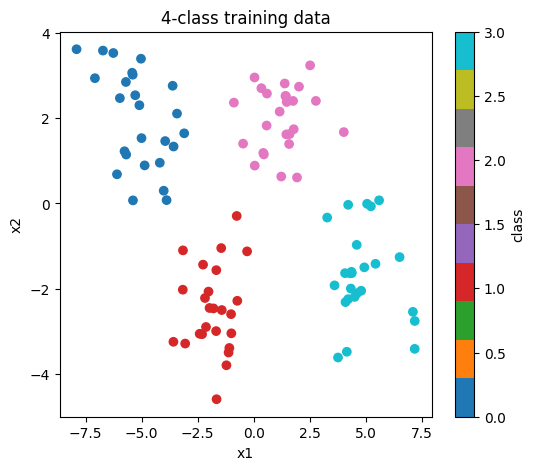

In [13]:
plt.figure(figsize = (6, 5))
plt.scatter(x_train[:, 0], x_train[:, 1], c = y_train, cmap = "tab10")
plt.title("4-class training data")
plt.xlabel("x1")
plt.ylabel("x2")
plt.colorbar(label="class")
plt.show()

## Build Neural Network

In [14]:
tf.random.set_seed(1234)

model = Sequential([
    Input(shape=(2,)),
    Dense(units=2, activation='relu', name='L1'),
    Dense(units=4, activation='linear', name='L2')
])

model.compile(
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer = tf.keras.optimizers.Adam(0.01),
    metrics = ['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ L1 (Dense)                           │ (None, 2)                   │               6 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ L2 (Dense)                           │ (None, 4)                   │              12 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 18 (72.00 B)

 Trainable params: 18 (72.00 B)

 Non-trainable params: 0 (0.00 B)

## Train Model

In [16]:
model.fit(x_train, y_train, epochs = 200, verbose = 0)
print("Training complete")

Training complete


In [17]:
probability_model = Sequential([
    model, 
    tf.keras.layers.Softmax()
])

## Plot Decision Boundaries

2813/2813 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step


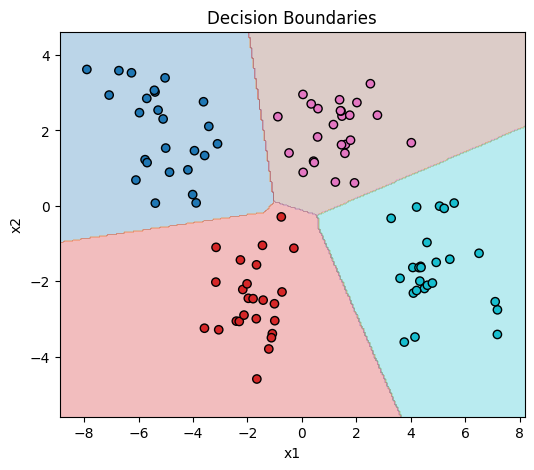

In [18]:
def plot_decision_boundary(model, X, y):
    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1
    
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )
    
    grid = np.c_[xx.ravel(), yy.ravel()]
    preds = model.predict(grid)
    Z = np.argmax(preds, axis=1)
    Z = Z.reshape(xx.shape)
    
    plt.figure(figsize=(6,5))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap="tab10")
    plt.scatter(X[:,0], X[:,1], c=y, cmap="tab10", edgecolors='k')
    plt.title("Decision Boundaries")
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.show()

plot_decision_boundary(probability_model, x_train, y_train)


## Predictions

In [19]:
x_test = np.array([
    [-4, 2],
    [-2, -1],
    [1, 3],
    [4, -2]
])

probs = probability_model.predict(x_test)
predictions = np.argmax(probs, axis = 1)
print("Test points:\n", x_test)
print("Predicted probabilities:\n", probs)
print("Predicted classes:\n", predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
Test points:
 [[-4  2]
 [-2 -1]
 [ 1  3]
 [ 4 -2]]
Predicted probabilities:
 [[9.9964583e-01 4.4807820e-09 3.5415892e-04 1.3309895e-13]
 [5.7716155e-03 9.8940200e-01 2.0413296e-03 2.7850973e-03]
 [1.3848914e-07 8.3570234e-11 9.9999988e-01 2.3819082e-09]
 [2.3482250e-13 2.0015097e-04 4.2095478e-03 9.9559033e-01]]
Predicted classes:
 [0 1 2 3]
